In [1]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
#Date="03.12.25"

ann_path="/home/davidvol/projects/phenomobile/images/HS/"
images_folder="/home/davidvol/projects/phenomobile/images/HS/images"

df=pd.read_csv(ann_path + "/bounding_boxes_BENI_ATAROT.csv")
df.head(2)

,label_name,bbox_x,bbox_y,bbox_width,bbox_height,image_name,image_width,image_height
0,G1,33,118,102,90,187.png,512,512
1,R1,21,202,124,83,187.png,512,512


In [ ]:
def plot_rgb_annotations(df,image_folder):
    for index, row in df.iterrows():
        img_path = os.path.join(image_folder, row['image_name'])
        image = cv2.imread(img_path)
        
        if image is None:
            continue
            
        h_img, w_img, _ = image.shape
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Coordinates
        x, y = int(row['bbox_x']), int(row['bbox_y'])
        w, h = int(row['bbox_width']), int(row['bbox_height'])
        
        # Draw the box and label
        cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 10)
        cv2.putText(image_rgb, str(row['label_name']), (x, y - 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 8)

        
        plt.imshow(image_rgb)
        plt.title(f"Corrected Annotation: {row['label_name']}")
        plt.axis('off')
        plt.show()

# Run the function. Change './' to the actual path where your images are stored.
plot_rgb_annotations(df,images_folder)

Found 4 unique image entries in the dataframe.


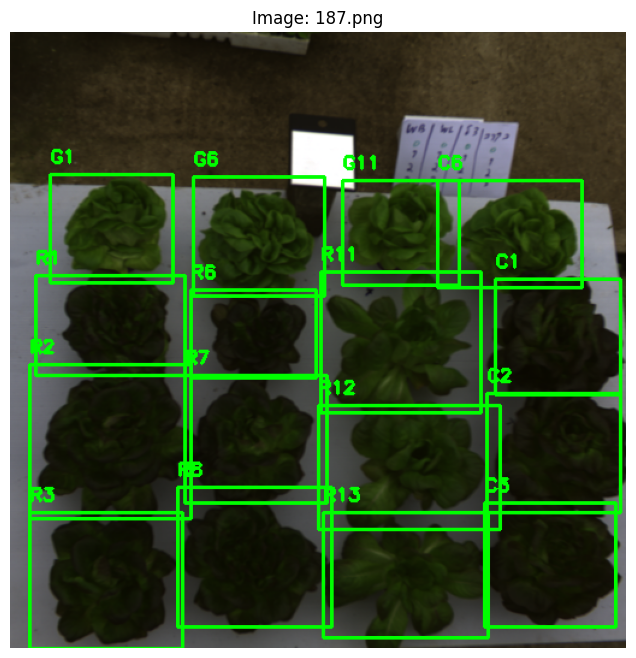

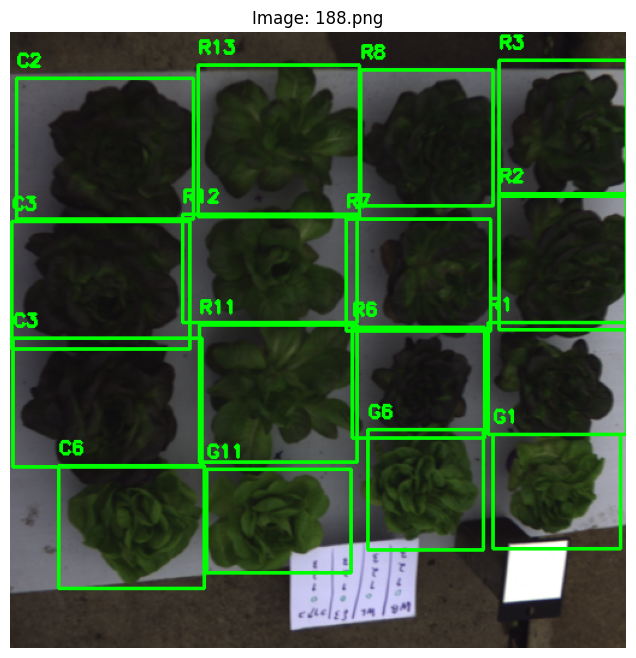

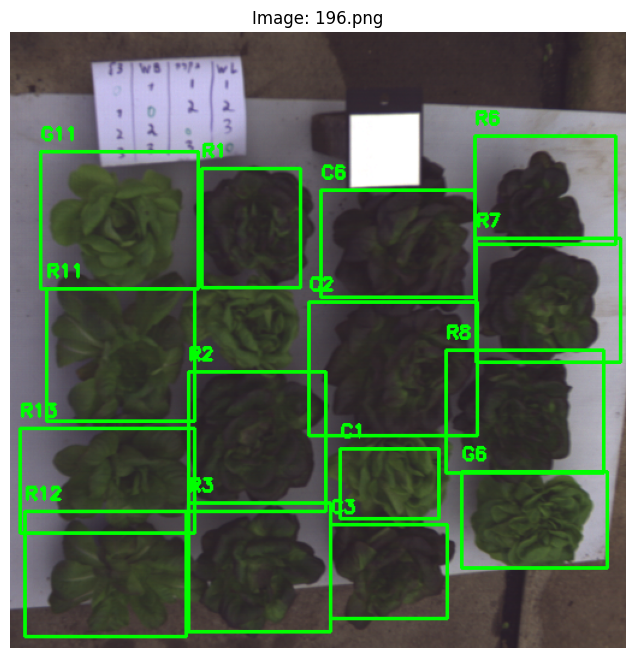

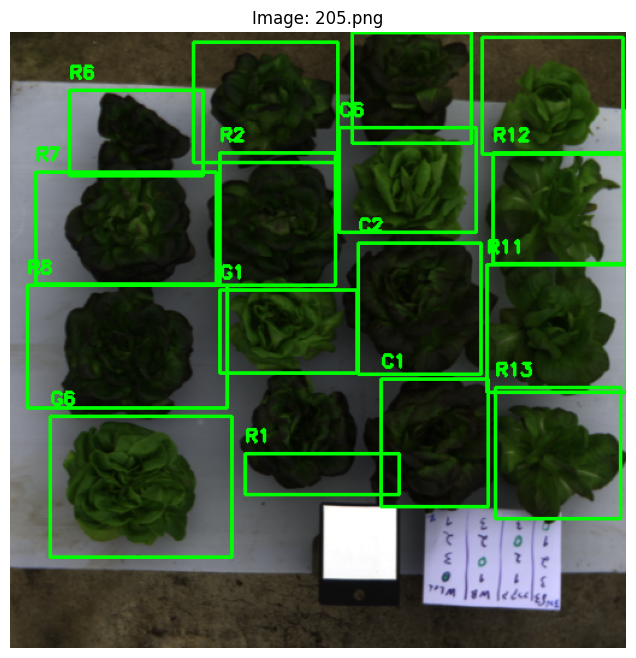

In [4]:


def plot_hs_annotations(df, image_dir):
    """
    Plots bounding boxes for each image listed in the dataframe.
    
    Args:
        df (pd.DataFrame): Dataframe with columns: 'label_name', 'bbox_x', 
                           'bbox_y', 'bbox_width', 'bbox_height', 'image_name'
        image_dir (str): Path to the folder containing the images.
    """
    unique_images = df['image_name'].unique()
    print(f"Found {len(unique_images)} unique image entries in the dataframe.")

    for img_name in unique_images:
        # 1. Filter the annotations for this specific image
        img_df = df[df['image_name'] == img_name]
        
        # 2. Find the image file (handling common extension mismatches)
        img_path = os.path.join(image_dir, img_name)
        if not os.path.exists(img_path):
            base_name = os.path.splitext(img_name)[0]
            for ext in ['.jpg', '.png', '.jpeg', '.JPG', '.PNG']:
                temp_path = os.path.join(image_dir, base_name + ext)
                if os.path.exists(temp_path):
                    img_path = temp_path
                    break
        
        if not os.path.exists(img_path):
            print(f"Skipping {img_name}: No matching image file found in {image_dir}")
            continue

        # 3. Load the image
        image = cv2.imread(img_path)
        if image is None:
            print(f"Error: Unable to open {img_path}")
            continue
            
        # 4. Draw each bounding box and its label
        for _, row in img_df.iterrows():
            # Extract coordinates and label
            x = int(row['bbox_x'])
            y = int(row['bbox_y'])
            w = int(row['bbox_width'])
            h = int(row['bbox_height'])
            label = str(row['label_name'])
            
            # Draw green rectangle (BGR color)
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
            # Draw label name above the box
            cv2.putText(image, label, (x, y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # 5. Display the result using Matplotlib (convert BGR to RGB first)
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(f"Image: {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()

# --- Example Usage ---

plot_hs_annotations(df, images_folder)